# Imports

In [11]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache # "Least Recently Used Cache" for recursive calls
import sys

sys.setrecursionlimit(10**7)

# Time Measurement function

In [15]:
def measure_time(func, *args, repeat=1000):
    start = time.perf_counter()

    for _ in range(repeat):
        func(*args)

    end = time.perf_counter()
    return (end - start) / repeat * 1000

### Task 1

In [13]:
def constant_time(arr):
    return arr[0]

def linear_time(arr):
    total = 0
    for x in arr:
        total += x
    return total

def quadratic_time(arr):
    total = 0
    n = len(arr)
    for i in range(n):
        for j in range(n):
            total += arr[i] + arr[j]
    return total

def logarithmic_time(n):
    count = 0
    while n > 1:
        n //= 2
        count += 1
    return count

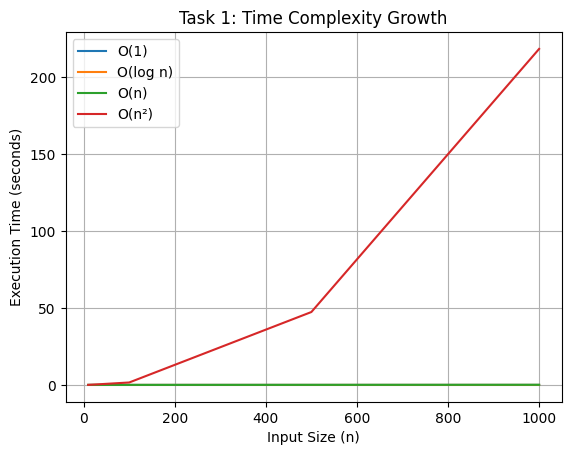

In [16]:
sizes = [10, 100, 500, 1000]
o1, on, on2, olog = [], [], [], []

for n in sizes:
    arr = list(range(n))
    o1.append(measure_time(constant_time, arr))
    on.append(measure_time(linear_time, arr))
    on2.append(measure_time(quadratic_time, arr))
    olog.append(measure_time(logarithmic_time, n))

plt.figure()
plt.plot(sizes, o1, label="O(1)")
plt.plot(sizes, olog, label="O(log n)")
plt.plot(sizes, on, label="O(n)")
plt.plot(sizes, on2, label="O(n²)")
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Task 1: Time Complexity Growth")
plt.legend()
plt.grid(True)
plt.show()

#### Observations:

The experimental results clearly demonstrate the difference in growth rates of algorithms with varying time complexities.

The constant-time algorithm remains nearly unchanged for all input sizes, confirming its O(1) behavior.
The logarithmic-time algorithm grows very slowly as the input size increases, which is characteristic of O(log n) complexity.

The linear-time algorithm shows a steady and proportional increase in execution time with respect to input size, validating its O(n) complexity.

The quadratic-time algorithm exhibits a rapid increase in execution time and dominates the graph for larger input sizes, confirming its O(n²) complexity.

The use of a logarithmic scale on the y-axis makes the relative growth trends clearly visible and aligns the experimental results with theoretical expectations.

### Task 2

In [7]:
def linear_search(arr, key):
    for i, x in enumerate(arr):
        if x == key:
            return i
    return -1

def binary_search(arr, key):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == key:
            return mid
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1
    return -1

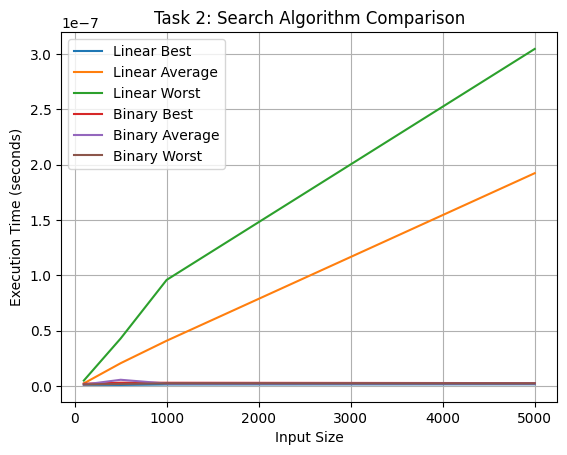

In [8]:
sizes = [100, 500, 1000, 5000]

lin_best, lin_avg, lin_worst = [], [], []
bin_best, bin_avg, bin_worst = [], [], []

for n in sizes:
    arr = list(range(n))
    random.shuffle(arr)
    arr_sorted = sorted(arr)

    lin_best.append(measure_time(linear_search, arr, arr[0]))
    lin_avg.append(measure_time(linear_search, arr, arr[n // 2]))
    lin_worst.append(measure_time(linear_search, arr, -1))

    bin_best.append(measure_time(binary_search, arr_sorted, arr_sorted[n // 2]))
    bin_avg.append(measure_time(binary_search, arr_sorted, random.choice(arr_sorted)))
    bin_worst.append(measure_time(binary_search, arr_sorted, -1))

plt.figure()
plt.plot(sizes, lin_best, label="Linear Best")
plt.plot(sizes, lin_avg, label="Linear Average")
plt.plot(sizes, lin_worst, label="Linear Worst")
plt.plot(sizes, bin_best, label="Binary Best")
plt.plot(sizes, bin_avg, label="Binary Average")
plt.plot(sizes, bin_worst, label="Binary Worst")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (seconds)")
plt.title("Task 2: Search Algorithm Comparison")
plt.legend()
plt.grid(True)
plt.show()

#### Observations:

Linear search shows a clear increase in execution time as the input size grows, particularly in the worst-case scenario where the element is absent or located at the end of the array. This confirms the O(n) time complexity of linear search.

Binary search demonstrates significantly lower execution times across all cases. Its performance improves as input size increases, validating its O(log n) complexity.

The best case for binary search remains nearly constant, while the average and worst cases grow very slowly compared to linear search.

These results highlight that although linear search is simple to implement, binary search is far more efficient for large datasets when the input is sorted.

### Task 3

In [18]:
fact_calls = 0
fib_calls = 0
fib_dp_calls = 0

def factorial(n):
    global fact_calls
    fact_calls += 1
    if n <= 1:
        return 1
    return n * factorial(n - 1)

def fibonacci_naive(n):
    global fib_calls
    fib_calls += 1
    if n <= 1:
        return n
    return fibonacci_naive(n - 1) + fibonacci_naive(n - 2)

@lru_cache(None)
def fibonacci_dp(n):
    global fib_dp_calls
    fib_dp_calls += 1
    if n <= 1:
        return n
    return fibonacci_dp(n - 1) + fibonacci_dp(n - 2)

In [25]:
def measure(func, n):
    start = time.perf_counter()
    func(n)
    end = time.perf_counter()
    return end - start

In [33]:
results = []

for n in [5, 10, 20]:
    fact_calls = fib_calls = fib_dp_calls = 0

    t_fact = measure_time(factorial, n)
    t_fib = measure_time(fibonacci_naive, n)

    fibonacci_dp.cache_clear()
    t_fib_dp = measure_time(fibonacci_dp, n)

    results.append([
        n,
        t_fact, fact_calls,
        t_fib, fib_calls,
        t_fib_dp, fib_dp_calls
    ])

df = pd.DataFrame(
    results,
    columns=[
        "n",
        "Factorial Time (s)", "Factorial Calls",
        "Fib Naive Time (s)", "Fib Naive Calls",
        "Fib DP Time (s)", "Fib DP Calls"
    ]
)
df

,n,Factorial Time (s),Factorial Calls,Fib Naive Time (s),Fib Naive Calls,Fib DP Time (s),Fib DP Calls
0,5,0.000307,25,0.000018,75,0.000004,6
1,10,0.000006,50,0.000063,885,0.000010,11
2,20,0.000017,100,0.010927,109455,0.000028,21


#### Observations:

The recursive factorial algorithm shows linear growth in both execution time and the number of function calls, as each recursive call reduces the problem size by one.

The naive recursive Fibonacci algorithm exhibits exponential growth in function calls and execution time. This is due to repeated computation of overlapping subproblems, which significantly degrades performance for larger inputs.

The dynamic programming implementation of Fibonacci drastically reduces both execution time and the number of function calls. By storing previously computed results, memoization eliminates redundant calculations.

The comparison clearly demonstrates how optimization techniques such as dynamic programming can transform an inefficient recursive algorithm into an efficient one with linear time complexity

### Task 4

In [20]:
rec1_calls = 0
rec2_calls = 0

def recurrence1(n):
    global rec1_calls
    rec1_calls += 1
    if n <= 1:
        return 1
    return recurrence1(n // 2) + n

def recurrence2(n):
    global rec2_calls
    rec2_calls += 1
    if n <= 1:
        return 1
    return recurrence2(n // 2) + recurrence2(n // 2) + n

In [23]:
sizes = [16, 32, 64, 128]
calls_1 = []
calls_2 = []

for n in sizes:
    rec1_calls = 0
    rec2_calls = 0

    recurrence_1(n)
    recurrence_2(n)

    calls_1.append(rec1_calls)
    calls_2.append(rec2_calls)

print("n\tT(n)=T(n/2)+n\tT(n)=2T(n/2)+n")
for i in range(len(sizes)):
    print(f"{sizes[i]}\t{calls_1[i]}\t\t{calls_2[i]}")

n	T(n)=T(n/2)+n	T(n)=2T(n/2)+n
16	5		31
32	6		63
64	7		127
128	8		255


### Observations:

For the recurrence T(n) = T(n/2) + n, the number of recursive calls increases logarithmically with input size. Each recursive step reduces the problem size by half, resulting in log₂(n) + 1 calls. This validates the expected time complexity of O(n).

For the recurrence T(n) = 2T(n/2) + n, the number of recursive calls grows linearly with input size. Each call branches into two subproblems, forming a complete binary recursion tree with n − 1 total calls. This experimentally confirms the O(n log n) time complexity derived using the Master Theorem.

The observed call counts closely match theoretical predictions, demonstrating consistency between empirical results and asymptotic analysis.